working with simulated data set


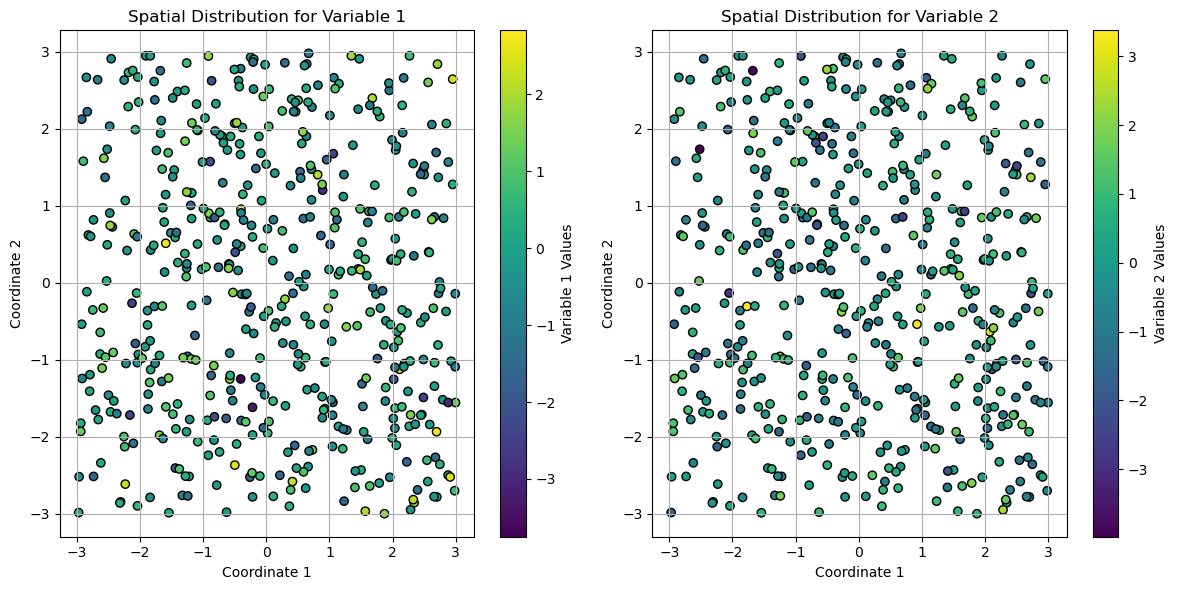

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 715.4576779087854
        x: [ 7.665e-01  1.418e+00  9.838e-01]
      nit: 17
      jac: [-5.002e-04  3.411e-05  2.399e-03]
     nfev: 76
     njev: 19
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>


  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 715.5654729147172
        x: [ 1.000e-01  7.639e-01  9.617e-01]
      nit: 7
      jac: [ 5.491e-02 -5.775e-03 -9.322e-04]
     nfev: 44
     njev: 11
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>


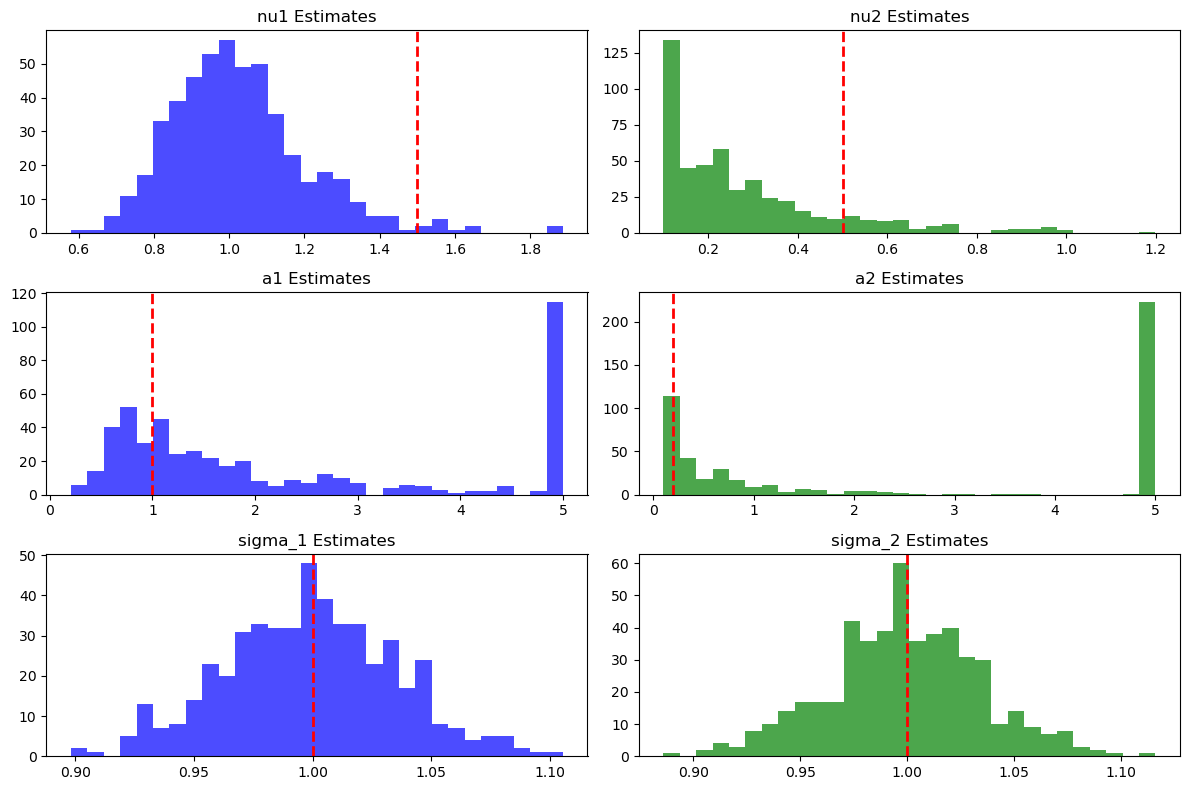

In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import sys
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import multivariate_normal
from sklearn.gaussian_process.kernels import Matern
from scipy.interpolate import griddata
from scipy.linalg import cho_solve, cho_factor
from scipy.optimize import minimize
# Define the Matern covariance function
def matern_covariance(X, length_scale=1.0, nu=1.5, sigma2=1.0):
    pairwise_dists = squareform(pdist(X, 'euclidean'))
    kernel = Matern(length_scale=length_scale, nu=nu)
    return sigma2 * kernel(pairwise_dists)

# Generate marginal Matern covariance matrix 
def generate_marginal_matern_covariance(X, params_marginal, nugget = 1e-1, sigma1=1, sigma2=2):
    a, nu, sigma = params_marginal
    K = matern_covariance(X, length_scale = a, nu=nu, sigma2=sigma**2)
    # Adding nugget effect to the diagonal blocks
    K += np.eye(K.shape[0]) * nugget
    return K

# Generate bivariate Matern covariance matrix with distinct parameters
def generate_bivariate_matern_covariance(X, params, nugget = 1e-1, sigma1=1, sigma2=2):
    nu1, a1, sigma_1, nu2, a2, sigma_2, nu12, a12, sigma_12 = params
    K1 = matern_covariance(X, length_scale=a1, nu=nu1, sigma2=sigma_1**2)
    K2 = matern_covariance(X, length_scale=a2, nu=nu2, sigma2=sigma_2**2)
    K12 = matern_covariance(X, length_scale=a12, nu=nu12, sigma2=sigma_12**2)
    K = np.block([[K1, K12], [K12.T, K2]])
    # Adding nugget effect to the diagonal blocks
    K += np.eye(K.shape[0]) * nugget
    return K

# Check if matrix is positive definite
def is_positive_definite(K):
    try:
        np.linalg.cholesky(K)
        return True
    except np.linalg.LinAlgError:
        return False

# Negative log-likelihood function for optimization
def negative_log_likelihood_marginal(params_marginal, X, y):
    K = generate_marginal_matern_covariance(X, params_marginal)
    if not is_positive_definite(K):
        # return sys.float_info.max # np.inf can lead to np.nan, so perhaps this is better.
        return np.inf
    
    try:
        L = cho_factor(K)
        alpha = cho_solve(L, y)
        log_likelihood = -0.5 * np.dot(y.T, alpha)
        log_likelihood -= np.sum(np.log(np.diag(L[0])))
        log_likelihood -= K.shape[0] / 2 * np.log(2 * np.pi)
        return -log_likelihood
    except np.linalg.LinAlgError:
        # return sys.float_info.max # np.inf can lead to np.nan, so perhaps this is better.
        return np.inf

# Plotting function for data and continuous fields
def plot_data_and_fields(X, data):
    # Plotting the data
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(X[:, 0], X[:, 1], c=data[:, 0], cmap='viridis', edgecolor='k')
    plt.colorbar(label='Variable 1 Values')
    plt.title('Spatial Distribution for Variable 1')
    plt.xlabel('Coordinate 1')
    plt.ylabel('Coordinate 2')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.scatter(X[:, 0], X[:, 1], c=data[:, 1], cmap='viridis', edgecolor='k')
    plt.colorbar(label='Variable 2 Values')
    plt.title('Spatial Distribution for Variable 2')
    plt.xlabel('Coordinate 1')
    plt.ylabel('Coordinate 2')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Simulate bivariate data
data_size = 500
X = np.random.uniform(-3., 3., (data_size, 2))
# Generate covariance matrix
mean = np.zeros(2 * len(X))
initial_params = [1.5, 1, 1, 0.5, 0.2,1,  1, 0.6, 0.5]
K = generate_bivariate_matern_covariance(X, initial_params)

# # Check if matrix is positive definite
# print("Is the covariance matrix positive definite?", is_positive_definite(K))

data = multivariate_normal.rvs(mean=mean, cov=K).reshape(-1, 2)
print("working with simulated data set")

# Generate and Flatten the data for optimization
y_data = data.reshape(-1)

# Plot the data and continuous fields
plot_data_and_fields(X, data)

y_data_first = y_data[:data_size]
y_data_second = y_data[data_size:]
# len(y_data_first)
# len(y_data_second)

def optimise_marginal (y_data = y_data_first):
    # Bounds and options for the optimizer
    bounds = [
        (0.1, 5.0),  # nu: smoothness parameter for the variable
        (0.1, 5.0),  # a: length scale for the variable
        (0.1, 5.0),      # sigma: standard deviation for the variable
    ]
    options = {'maxiter': 10000, 'gtol': 1e-15}
    initial_params_marginal = [1.0, 1.0, 1.0]
    
    # Minimize the negative log-likelihood
    result = minimize(negative_log_likelihood_marginal, initial_params_marginal, args=(X, y_data), bounds=bounds, options=options)
    # Output the optimal parameters with descriptions
    # print("Optimal marginal parameters of the variable:")
    # print(result.x)
    # print("Success:", result.success)
    # print("Message:", result.message)
    # print("Number of iterations:", result.nit)
    return result
    
result_first = optimise_marginal(y_data_first)    
print(result_first)

result_second = optimise_marginal(y_data_second)
print(result_second)

def simulate_data(data_size = 500):
    X = np.random.uniform(-3., 3., (data_size, 2))
    # Generate covariance matrix
    mean = np.zeros(2 * len(X))
    initial_params = [1.5, 1, 1, 0.5, 0.2, 1,  1, 0.6, 0.5]
    K = generate_bivariate_matern_covariance(X, initial_params)    
    data = multivariate_normal.rvs(mean=mean, cov=K).reshape(-1, 2)
    
    # Generate and Flatten the data for optimization
    y_data = data.reshape(-1)
    y_data_first = y_data[:data_size]
    y_data_second = y_data[data_size:]
    return (X, y_data, y_data_first, y_data_second)


# Initialize lists to store the results
nu1_estimates = []
a1_estimates = []
sigma_1_estimates = []
nu2_estimates = []
a2_estimates = []
sigma_2_estimates = []

counter = 500  # Number of iterations

for _ in range(counter):
    X, y_data, y_data_first, y_data_second = simulate_data(data_size=500)
    result_first = optimise_marginal(y_data_first)
    result_second = optimise_marginal(y_data_second)
    
    nu1_estimated, a1_estimated, sigma_1_estimated = result_first.x
    nu2_estimated, a2_estimated, sigma_2_estimated = result_second.x
    
    nu1_estimates.append(nu1_estimated)
    a1_estimates.append(a1_estimated)
    sigma_1_estimates.append(sigma_1_estimated)
    nu2_estimates.append(nu2_estimated)
    a2_estimates.append(a2_estimated)
    sigma_2_estimates.append(sigma_2_estimated)


# Ground truth values
nu1_truth, a1_truth, sigma_1_truth, nu2_truth, a2_truth, sigma_2_truth, nu12, a12, rho = [1.5, 1, 1, 0.5, 0.2, 1, 1, 0.6, 0.5]

# Plotting histograms
plt.figure(figsize=(12, 8))

plt.subplot(3, 2, 1)
plt.hist(nu1_estimates, bins=30, color='blue', alpha=0.7)
plt.axvline(nu1_truth, color='red', linestyle='dashed', linewidth=2)
plt.title('nu1 Estimates')

plt.subplot(3, 2, 2)
plt.hist(nu2_estimates, bins=30, color='green', alpha=0.7)
plt.axvline(nu2_truth, color='red', linestyle='dashed', linewidth=2)
plt.title('nu2 Estimates')

plt.subplot(3, 2, 3)
plt.hist(a1_estimates, bins=30, color='blue', alpha=0.7)
plt.axvline(a1_truth, color='red', linestyle='dashed', linewidth=2)
plt.title('a1 Estimates')

plt.subplot(3, 2, 4)
plt.hist(a2_estimates, bins=30, color='green', alpha=0.7)
plt.axvline(a2_truth, color='red', linestyle='dashed', linewidth=2)
plt.title('a2 Estimates')

plt.subplot(3, 2, 5)
plt.hist(sigma_1_estimates, bins=30, color='blue', alpha=0.7)
plt.axvline(sigma_1_truth, color='red', linestyle='dashed', linewidth=2)
plt.title('sigma_1 Estimates')

plt.subplot(3, 2, 6)
plt.hist(sigma_2_estimates, bins=30, color='green', alpha=0.7)
plt.axvline(sigma_2_truth, color='red', linestyle='dashed', linewidth=2)
plt.title('sigma_2 Estimates')

plt.tight_layout()
plt.show()